# 4_EDA

**Objective:**
This notebook performs an in-depth exploratory data analysis (EDA) on the finalized SEO dataset by:

- Computing and visualizing underpricing metrics (UnderPricing_PCT) after filtering out missing and extreme values.

- Exploring distributional characteristics such as mean, skewness, and outliers.

- Investigating how underpricing varies by categorical features such as:

    - VC-backed status

    - Issue Type

    - Industry group

    - Market Area

    - Security type

    - Marketplace

    - S&P Quality Ranking

    - Offer Month

- Visualizing underpricing trends across U.S. states using bar charts and choropleth maps.

- Calculating correlations between underpricing and macro/financial factors using:

    - Scatter plots for top correlated variables

    - Heatmaps for selected categorical segments (e.g., industries)

- Generating industry-specific correlation profiles for feature insight and model preparation.

In [21]:
# ===========================================
# 1. Import Required Libraries
# ===========================================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew
from matplotlib.ticker import PercentFormatter


In [22]:
# ===========================================
# 2. Load Enriched SEO Dataset
# ===========================================
file_path = r'data\Updated SEO ISSUES Dataset\seo_with_factors_Consumption_GDP.parquet'

# Load dataset and clean column names
data = pd.read_parquet(file_path)
data.columns = data.columns.str.strip()  # Remove any trailing spaces
df = data.copy()


In [23]:
# ===========================================
# 3. Filter Out Incomplete Records
# ===========================================

# Count original number of rows
original_count = len(df)

# Define missing data conditions
missing_close_price = df['Price_at_Close_Issue_Date'].isna()
missing_offer_price = df['Offer_Price_USD'].isna()

# Count how many rows meet each condition
filtered_close_price = missing_close_price.sum()
filtered_offer_price = missing_offer_price.sum()

# Apply filters to remove incomplete rows
df = df[~missing_close_price & ~missing_offer_price]

# Final count after filtering
final_count = len(df)
total_filtered = original_count - final_count

# Print summary
print(f"Original rows: {original_count}")
print(f"Filtered out due to missing Price_at_Close_Issue_Date: {filtered_close_price}")
print(f"Filtered out due to missing Offer_Price_USD: {filtered_offer_price}")
print(f"Total rows after filtering: {final_count}")
print(f"Total rows filtered out: {total_filtered}")


Original rows: 13755
Filtered out due to missing Price_at_Close_Issue_Date: 1999
Filtered out due to missing Offer_Price_USD: 0
Total rows after filtering: 11756
Total rows filtered out: 1999


In [24]:
# ===========================================
# 4. Drop Columns Dominated by a Single Value
# ===========================================

threshold = 1.00  # 100% dominance

# Identify columns where the top value accounts for 100% of data
dominated_cols = []
for col in df.columns:
    top_freq = df[col].value_counts(normalize=True, dropna=False).values[0]
    if top_freq >= threshold:
        dominated_cols.append(col)

print(f"Columns dominated by a single value (≥{threshold*100:.0f}%):")
print(dominated_cols)

# Drop dominated columns
df.drop(columns=dominated_cols, inplace=True)


Columns dominated by a single value (≥100%):
['sp500_Monthly_return', 'sp500_Weekly_return', 'sp500_Daily_return']


In [25]:
# ===========================================
# 5. Construct Underpricing Target Variable
# ===========================================

# Calculate dollar underpricing
df['UnderPricing'] = df['Price_at_Close_Issue_Date'] - df['Offer_Price_USD']

# Calculate percentage underpricing relative to offer price
df['UnderPricing_PCT'] = df['UnderPricing'] / df['Offer_Price_USD']


In [26]:
# ===========================================
# 6. Outlier Removal using IQR Method
# ===========================================

# Compute interquartile range for UnderPricing_PCT
Q1 = df['UnderPricing_PCT'].quantile(0.25)
Q3 = df['UnderPricing_PCT'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out rows beyond the bounds
df_filtered = df[(df['UnderPricing_PCT'] >= lower_bound) & (df['UnderPricing_PCT'] <= upper_bound)]


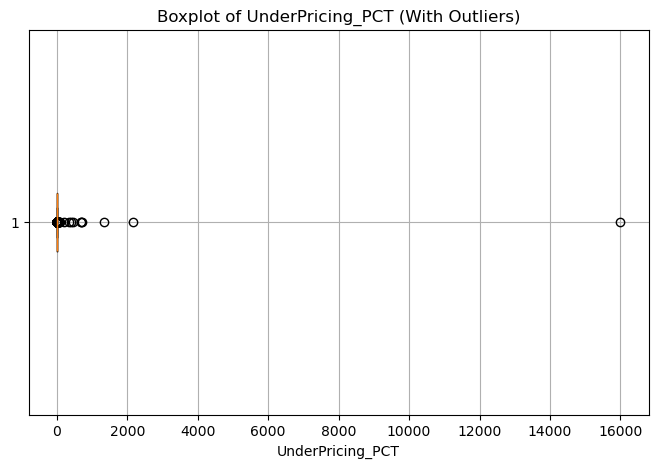

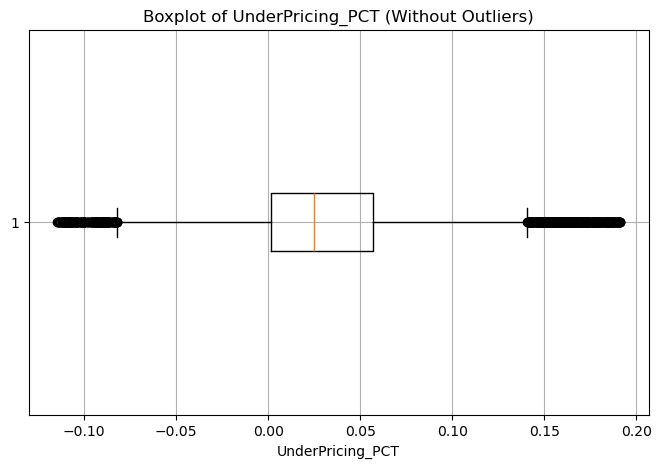

In [27]:
# ===========================================
# 7. Visualize UnderPricing_PCT Distribution
# ===========================================

# Boxplot before outlier removal
plt.figure(figsize=(8, 5))
plt.boxplot(df['UnderPricing_PCT'], vert=False)
plt.title('Boxplot of UnderPricing_PCT (With Outliers)')
plt.xlabel('UnderPricing_PCT')
plt.grid(True)
plt.show()

# Boxplot after outlier removal
plt.figure(figsize=(8, 5))
plt.boxplot(df_filtered['UnderPricing_PCT'], vert=False)
plt.title('Boxplot of UnderPricing_PCT (Without Outliers)')
plt.xlabel('UnderPricing_PCT')
plt.grid(True)
plt.show()


In [28]:
# ===========================================
# 8. Fill Missing Percent Change Columns with Zero
# ===========================================

cols_to_fill = [
    'Disposable personal income PCT change', 'Gross domestic product (GDP) PCT change',
    'Implicit regional price deflator 10 PCT change', 'Per capita disposable personal income 7 PCT change',
    'Per capita personal consumption expenditures (PCE) 8 PCT change', 'Per capita personal income 6 PCT change',
    'Personal consumption expenditures PCT change', 'Personal income PCT change',
    'Real GDP (millions of chained 2017 dollars) 1 PCT change',
    'Real PCE (millions of constant (2017) dollars) 3 PCT change',
    'Real per capita PCE 5 PCT change', 'Real per capita personal income 4 PCT change',
    'Real personal income (millions of constant (2017) dollars) 2 PCT change',
    'Regional price parities (RPPs) 9 PCT change', 'Total employment (number of jobs) PCT change',
    'Population (midperiod, persons) 1 QoQ change'
]

# Count NaNs before filling
na_counts_before = df_filtered[cols_to_fill].isna().sum()

# Fill NaNs with 0
df_filtered[cols_to_fill] = df_filtered[cols_to_fill].fillna(0)

# Display how many NaNs were filled per column
print("NaN values filled per column:")
print(na_counts_before)
print(f"\nTotal rows filled: {na_counts_before.sum()}")


NaN values filled per column:
Disposable personal income PCT change                                       839
Gross domestic product (GDP) PCT change                                     839
Implicit regional price deflator 10 PCT change                             2152
Per capita disposable personal income 7 PCT change                          839
Per capita personal consumption expenditures (PCE) 8 PCT change             839
Per capita personal income 6 PCT change                                     839
Personal consumption expenditures PCT change                                839
Personal income PCT change                                                  839
Real GDP (millions of chained 2017 dollars) 1 PCT change                    839
Real PCE (millions of constant (2017) dollars) 3 PCT change                 839
Real per capita PCE 5 PCT change                                            839
Real per capita personal income 4 PCT change                                839
Real perso

C:\Users\sjen591\AppData\Local\Temp\ipykernel_20444\3427019998.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered[cols_to_fill] = df_filtered[cols_to_fill].fillna(0)


C:\Users\sjen591\AppData\Local\Temp\ipykernel_20444\1743233396.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.rename(columns={'state': 'HQ_State'}, inplace=True)


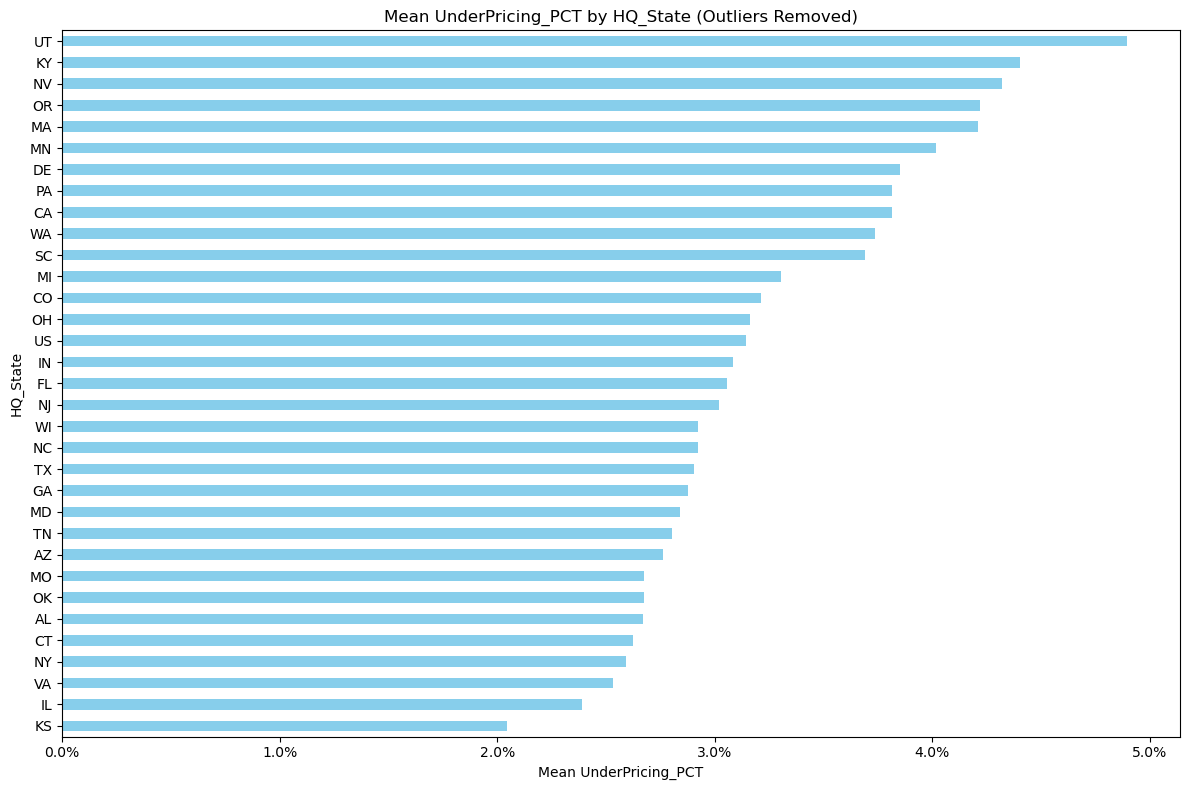

In [29]:
# ===========================================
# 9. Mean Underpricing by HQ State (Bar Chart)
# ===========================================

# Clean state column name
df_filtered.rename(columns={'state': 'HQ_State'}, inplace=True)

# Filter states with more than 20 SEO events
state_counts = df_filtered['HQ_State'].value_counts()
valid_states = state_counts[state_counts > 20].index
df_plot = df_filtered[df_filtered['HQ_State'].isin(valid_states)]

# Calculate mean underpricing per state
mean_underpricing = df_plot.groupby('HQ_State')['UnderPricing_PCT'].mean().sort_values()

# Plot horizontal bar chart
plt.figure(figsize=(12, 8))
ax = mean_underpricing.plot(kind='barh', color='skyblue')
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.title('Mean UnderPricing_PCT by HQ_State (Outliers Removed)')
plt.xlabel('Mean UnderPricing_PCT')
plt.ylabel('HQ_State')
plt.tight_layout()
plt.show()

# Save to CSV
mean_underpricing_df = mean_underpricing.reset_index()
mean_underpricing_df.columns = ['HQ_State', 'Mean_UnderPricing_PCT']
mean_underpricing_df.to_csv('mean_underpricing_by_state.csv', index=False)


In [30]:
# ===========================================
# 10. Mean Underpricing by State (Choropleth Map)
# ===========================================

import plotly.express as px

# Mapping from state abbreviations to full names
state_code_to_name = {
    'KS': 'Kansas', 'VA': 'Virginia', 'IL': 'Illinois', 'AZ': 'Arizona',
    'NY': 'New York', 'AL': 'Alabama', 'WI': 'Wisconsin', 'OK': 'Oklahoma',
    'CT': 'Connecticut', 'TX': 'Texas', 'MD': 'Maryland', 'TN': 'Tennessee',
    'NC': 'North Carolina', 'NJ': 'New Jersey', 'MO': 'Missouri', 'US': 'United States',
    'FL': 'Florida', 'IN': 'Indiana', 'GA': 'Georgia', 'MI': 'Michigan',
    'SC': 'South Carolina', 'CO': 'Colorado', 'WA': 'Washington', 'OH': 'Ohio',
    'PA': 'Pennsylvania', 'CA': 'California', 'DE': 'Delaware', 'MA': 'Massachusetts',
    'NV': 'Nevada', 'UT': 'Utah', 'MN': 'Minnesota'
}

# Add full state names
mean_underpricing_df['State_Name'] = mean_underpricing_df['HQ_State'].map(state_code_to_name)

# Create choropleth map
fig = px.choropleth(
    mean_underpricing_df,
    locations='HQ_State',
    locationmode='USA-states',
    color='Mean_UnderPricing_PCT',
    color_continuous_scale='Blues',
    scope='usa',
    labels={'Mean_UnderPricing_PCT': 'Mean Underpricing %'},
    title='Mean UnderPricing_PCT by State (Outliers Removed)',
    hover_name='State_Name'
)

# Customize hover tooltip and layout
fig.update_traces(
    hovertemplate='<b>%{customdata[0]}</b><br>Underpricing: %{z:.2%}<extra></extra>',
    customdata=mean_underpricing_df[['State_Name']]
)
fig.update_layout(
    width=1000,
    height=700,
    title_x=0.5
)

fig.show()


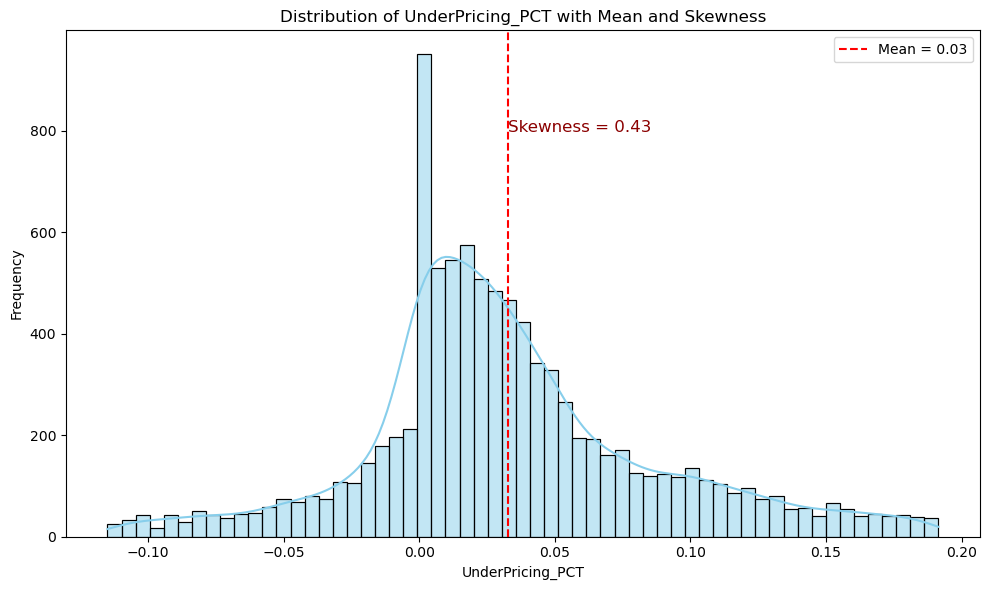

In [31]:
# ===========================================
# 11. UnderPricing_PCT Distribution with Skewness
# ===========================================

from scipy.stats import skew
import seaborn as sns

Underpricing_data = df_filtered['UnderPricing_PCT'].dropna()
mean_val = Underpricing_data.mean()
skew_val = skew(Underpricing_data)

plt.figure(figsize=(10, 6))
sns.histplot(Underpricing_data, kde=True, color='skyblue', edgecolor='black')
plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean = {mean_val:.2f}')
plt.text(mean_val, plt.ylim()[1]*0.8, f'Skewness = {skew_val:.2f}', color='darkred', fontsize=12)
plt.title('Distribution of UnderPricing_PCT with Mean and Skewness')
plt.xlabel('UnderPricing_PCT')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()


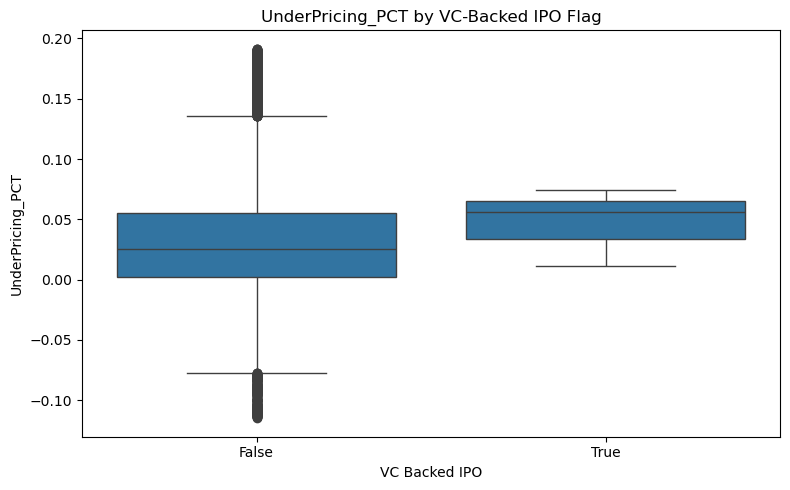

In [32]:
# ===========================================
# 12. Boxplot: UnderPricing_PCT by VC-Backed Flag
# ===========================================

# Filter and clean VC flag column
df_plot = df_filtered[df_filtered['VC_Backed_IPO_Issue_Flag'].notna()].copy()
df_plot['VC_Backed_IPO_Issue_Flag'] = df_plot['VC_Backed_IPO_Issue_Flag'].astype(str)

# Boxplot comparison
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_plot, x='VC_Backed_IPO_Issue_Flag', y='UnderPricing_PCT')
plt.title('UnderPricing_PCT by VC-Backed IPO Flag')
plt.xlabel('VC Backed IPO')
plt.ylabel('UnderPricing_PCT')
plt.tight_layout()
plt.show()


C:\Users\sjen591\AppData\Local\Temp\ipykernel_20444\644009830.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




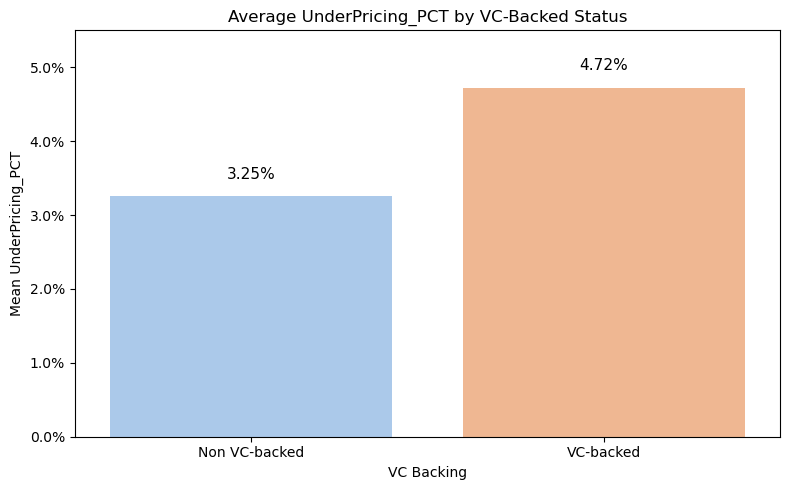

In [33]:
# ===========================================
# 13. Bar Plot: Average UnderPricing_PCT by VC-Backed Status
# ===========================================

# Remap VC flag to readable labels
df_plot['VC_Backed_IPO_Issue_Flag'] = df_plot['VC_Backed_IPO_Issue_Flag'].map({
    True: 'VC-backed', False: 'Non VC-backed',
    'True': 'VC-backed', 'False': 'Non VC-backed'
})

# Calculate group averages
mean_values = df_plot.groupby('VC_Backed_IPO_Issue_Flag')['UnderPricing_PCT'].mean().reset_index()

# Barplot
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=mean_values, x='VC_Backed_IPO_Issue_Flag', y='UnderPricing_PCT', palette='pastel')

# Add percentage labels
for i, row in mean_values.iterrows():
    ax.text(i, row['UnderPricing_PCT'] + 0.002, f"{row['UnderPricing_PCT']:.2%}", 
            color='black', ha='center', va='bottom', fontsize=11)

ax.set_ylim(0, 0.055)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.title('Average UnderPricing_PCT by VC-Backed Status')
plt.xlabel('VC Backing')
plt.ylabel('Mean UnderPricing_PCT')
plt.tight_layout()
plt.show()


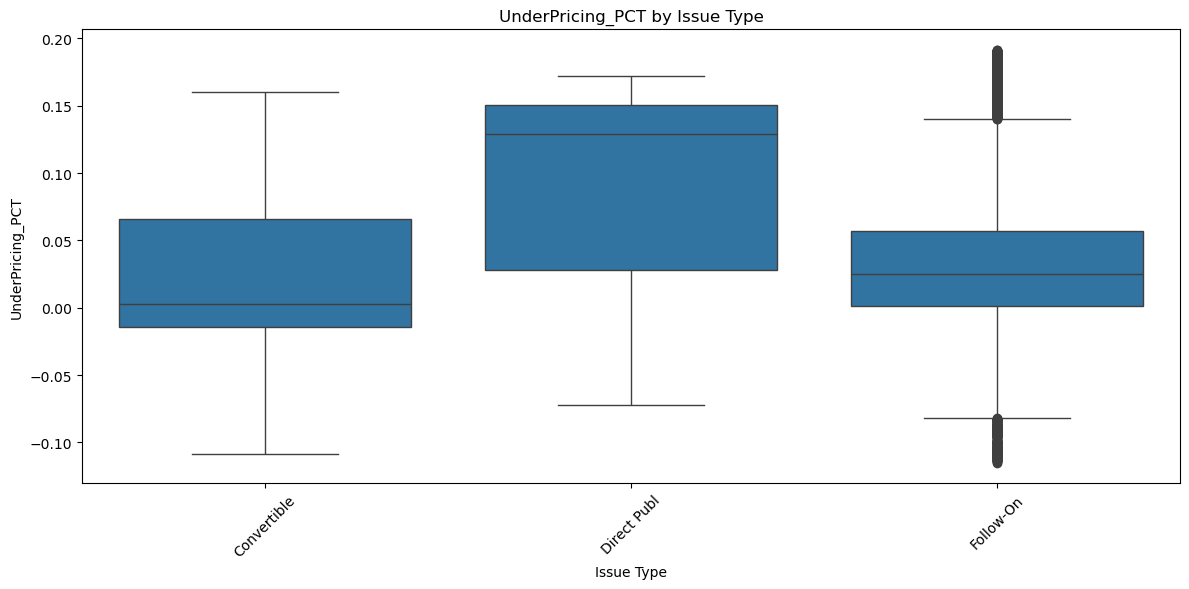

In [34]:
# ===========================================
# 14. Filter and analyze UnderPricing_PCT by Issue Type (Boxplot)
# ===========================================
df_issue_plot = df_filtered[df_filtered['Issue_Type'].notna() & (df_filtered['Issue_Type'].str.strip() != '')]
top_issue_types = df_issue_plot['Issue_Type'].value_counts().nlargest(10).index
df_issue_plot = df_issue_plot[df_issue_plot['Issue_Type'].isin(top_issue_types)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_issue_plot, x='Issue_Type', y='UnderPricing_PCT')
plt.title('UnderPricing_PCT by Issue Type')
plt.xlabel('Issue Type')
plt.ylabel('UnderPricing_PCT')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\sjen591\AppData\Local\Temp\ipykernel_20444\3763746428.py:7: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\sjen591\AppData\Local\Temp\ipykernel_20444\3763746428.py:10: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.


C:\Users\sjen591\AppData\Local\Temp\ipykernel_20444\3763746428.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




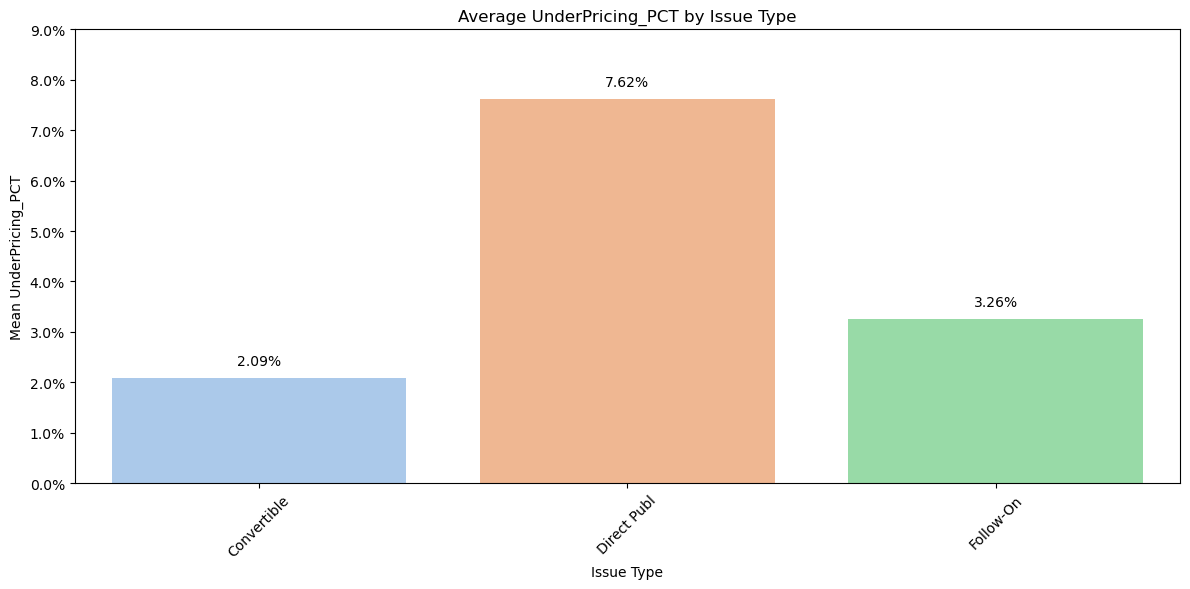

In [35]:
# ===========================================
# 15. Average UnderPricing_PCT by Issue Type (Bar Plot)
# ===========================================
df_issue_plot = df_filtered[df_filtered['Issue_Type'].notna() & (df_filtered['Issue_Type'].str.strip() != '')].copy()
top_issue_types = df_issue_plot['Issue_Type'].value_counts().nlargest(10).index
df_issue_plot = df_issue_plot[df_issue_plot['Issue_Type'].isin(top_issue_types)]
mean_issue = df_issue_plot.groupby('Issue_Type')['UnderPricing_PCT'].mean().reset_index()

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=mean_issue, x='Issue_Type', y='UnderPricing_PCT', palette='pastel', ci=None)
for i, row in mean_issue.iterrows():
    ax.text(i, row['UnderPricing_PCT'] + 0.002, f"{row['UnderPricing_PCT']:.2%}", ha='center', va='bottom')
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.title('Average UnderPricing_PCT by Issue Type')
plt.xlabel('Issue Type')
plt.ylabel('Mean UnderPricing_PCT')
plt.xticks(rotation=45)
plt.ylim(0, 0.09)
plt.tight_layout()
plt.show()


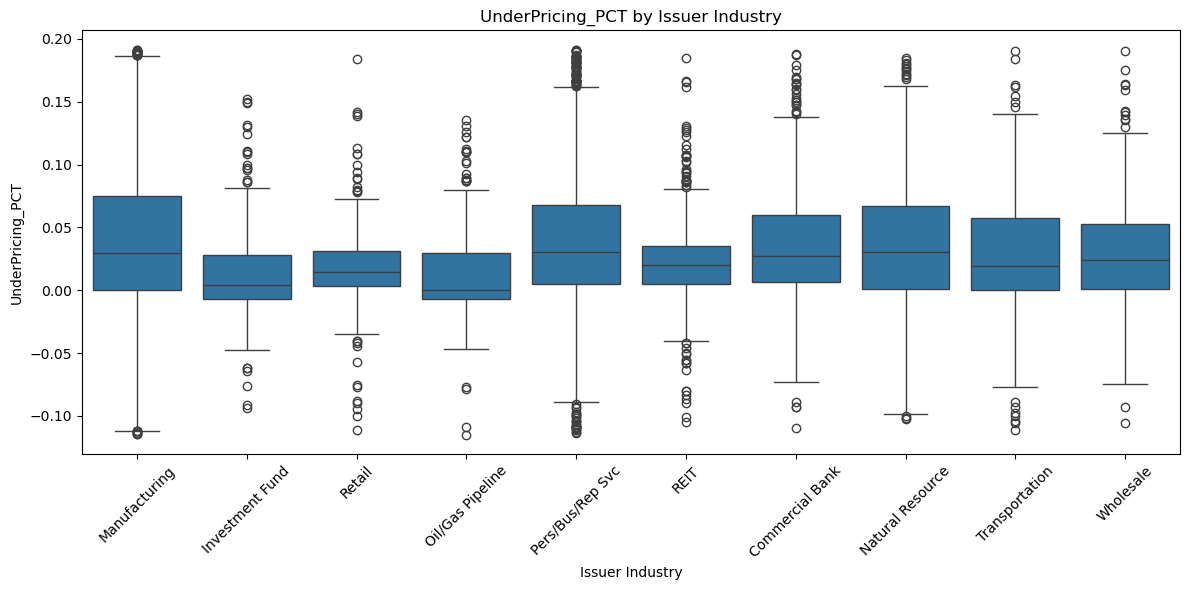

In [36]:
# ===========================================
# 16. UnderPricing_PCT by Issuer Industry (Boxplot)
# ===========================================
df_issue_plot = df_filtered[df_filtered['Issuer_SDC_Industry'].notna() & (df_filtered['Issuer_SDC_Industry'].str.strip() != '')]
top_issue_types = df_issue_plot['Issuer_SDC_Industry'].value_counts().nlargest(10).index
df_issue_plot = df_issue_plot[df_issue_plot['Issuer_SDC_Industry'].isin(top_issue_types)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_issue_plot, x='Issuer_SDC_Industry', y='UnderPricing_PCT')
plt.title('UnderPricing_PCT by Issuer Industry')
plt.xlabel('Issuer Industry')
plt.ylabel('UnderPricing_PCT')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


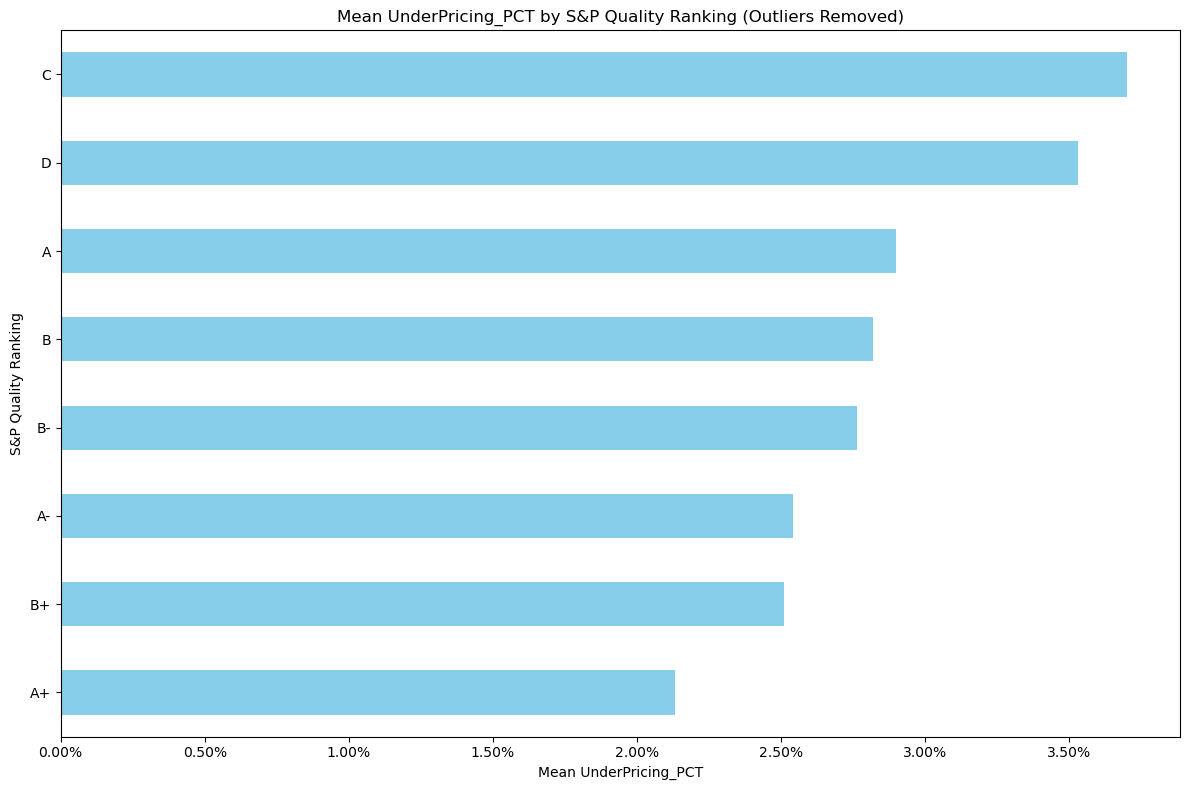

In [37]:
ranking_counts = df_filtered['S_P_Quality_Ranking'].value_counts()
valid_rankings = ranking_counts[ranking_counts > 20].index
df_plot = df_filtered[df_filtered['S_P_Quality_Ranking'].isin(valid_rankings)]

mean_underpricing = df_plot.groupby('S_P_Quality_Ranking')['UnderPricing_PCT'].mean().sort_values()

plt.figure(figsize=(12, 8))
ax = mean_underpricing.plot(kind='barh', color='skyblue')
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.title('Mean UnderPricing_PCT by S&P Quality Ranking (Outliers Removed)')
plt.xlabel('Mean UnderPricing_PCT')
plt.ylabel('S&P Quality Ranking')
plt.tight_layout()
plt.show()


In [38]:
# Drop columns not needed for modeling
df_filtered.drop(columns=[
    'Price_Date_Diff', 'Offer_Year', 'Issuer_Name_Full', 'Issuer_CUSIP8', 'Issuer_CUSIP9',
    'Price_at_Close_Issue_Date', 'Price_at_Close_Offer_Date', 'cik', 'cleaned_cik',
    'Offer_Quarter', 'Primary_Amt_Offered_All_Mkts', 'Primary_Amt_Offered_This_Mkt', 'UnderPricing'
], inplace=True)

# Create new feature: percentage of shares offered
df_filtered['Shares_Offered_This_Mkt_PCT'] = df_filtered['Shares_Offered_This_Mkt'] / df_filtered['Shares_Offered_All_Mkts']
df_filtered.drop(columns='Shares_Offered_This_Mkt', inplace=True)

# Row-wise completeness score
df_filtered['Completeness_Score'] = df_filtered.notna().sum(axis=1) / df_filtered.shape[1]


C:\Users\sjen591\AppData\Local\Temp\ipykernel_20444\3828617954.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\sjen591\AppData\Local\Temp\ipykernel_20444\3828617954.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\sjen591\AppData\Local\Temp\ipykernel_20444\3828617954.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\sjen591\AppData\Local\Temp\

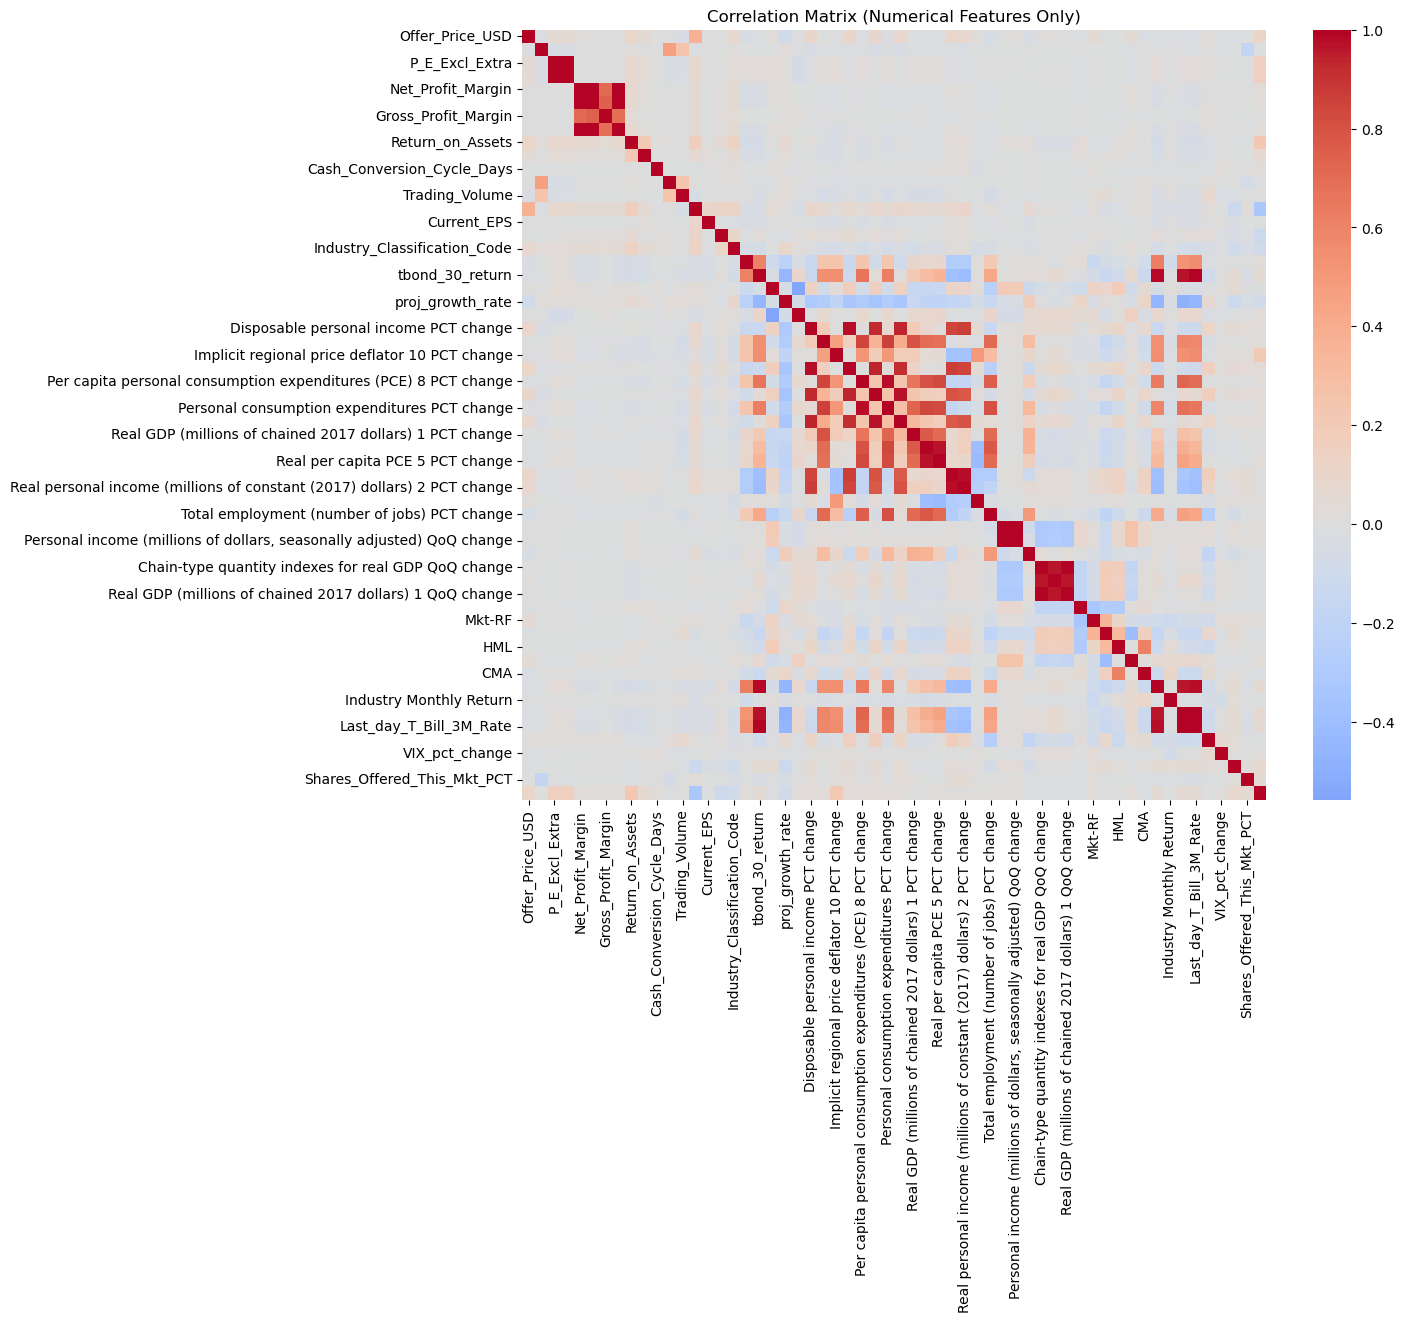

In [39]:
plt.figure(figsize=(12,10))
sns.heatmap(df_filtered.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Correlation Matrix (Numerical Features Only)')
plt.show()


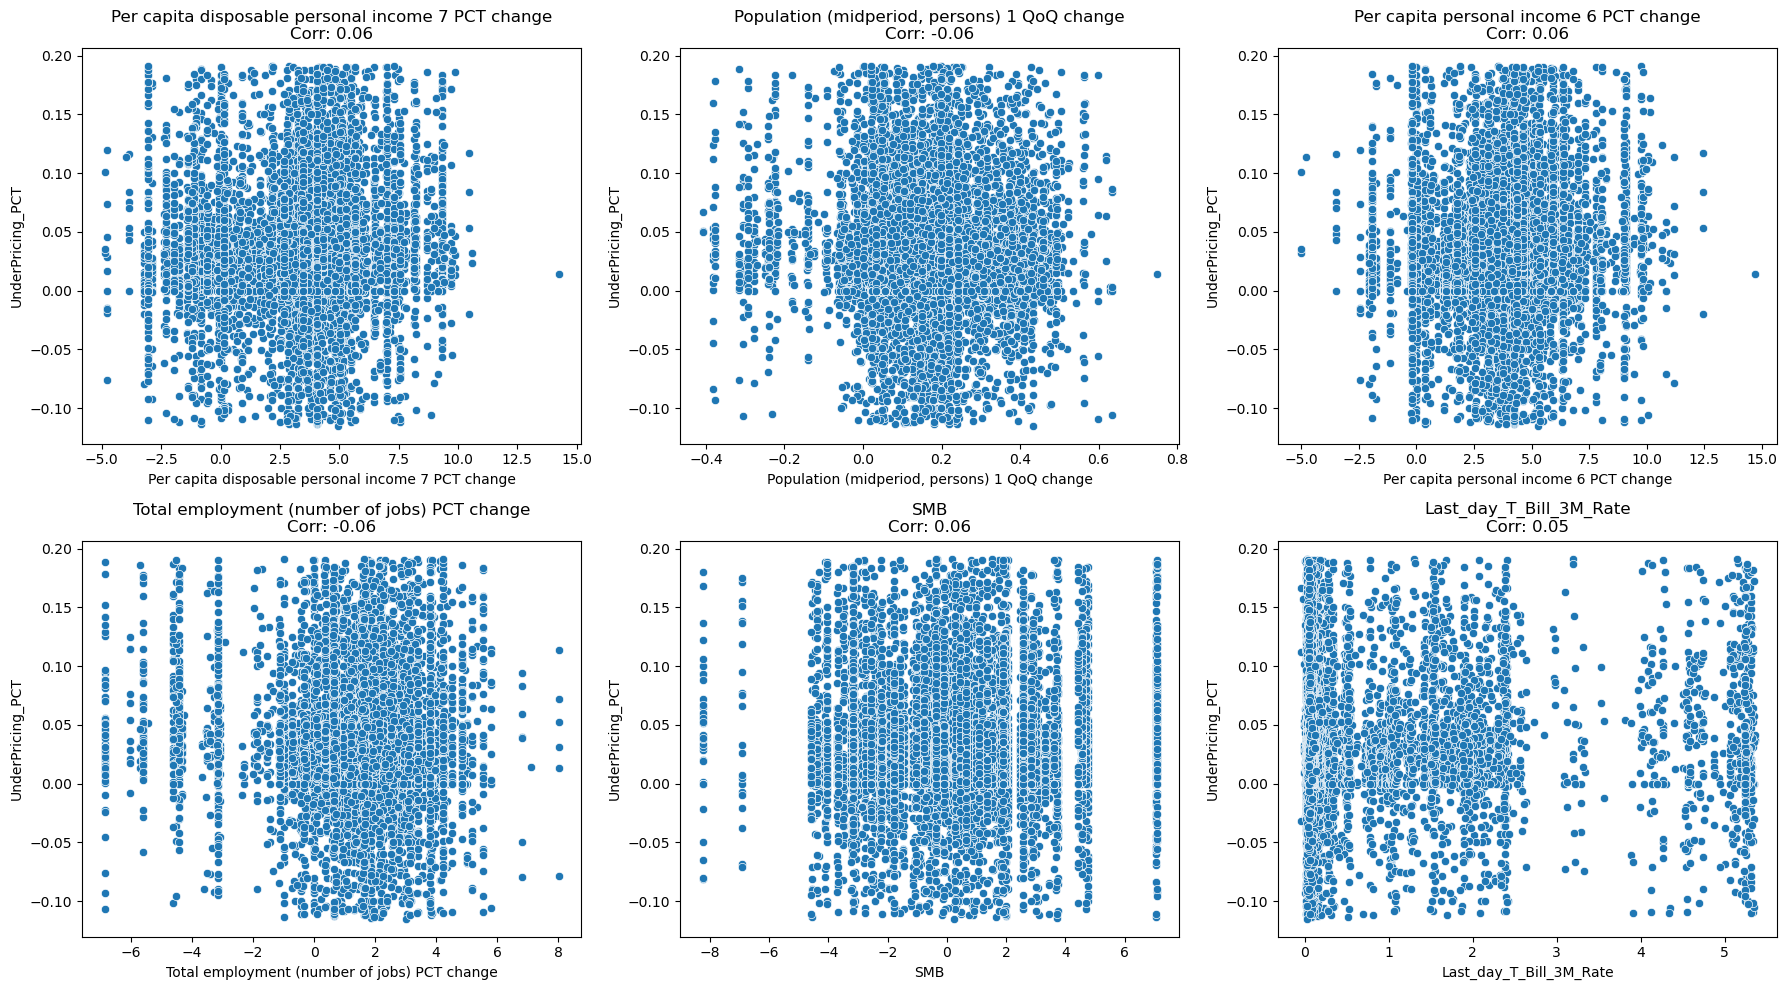

In [40]:
# Select key economic factors
econ_factors = [
    'Disposable personal income PCT change', 'Gross domestic product (GDP) PCT change',
    'Implicit regional price deflator 10 PCT change', 'Per capita disposable personal income 7 PCT change',
    'Per capita personal consumption expenditures (PCE) 8 PCT change', 'Per capita personal income 6 PCT change',
    'Personal consumption expenditures PCT change', 'Personal income PCT change',
    'Real GDP (millions of chained 2017 dollars) 1 PCT change',
    'Real PCE (millions of constant (2017) dollars) 3 PCT change',
    'Real per capita PCE 5 PCT change', 'Real per capita personal income 4 PCT change',
    'Real personal income (millions of constant (2017) dollars) 2 PCT change',
    'Regional price parities (RPPs) 9 PCT change', 'Total employment (number of jobs) PCT change',
    'Per capita personal income (dollars) 2 QoQ change', 'Personal income (millions of dollars, seasonally adjusted) QoQ change',
    'Population (midperiod, persons) 1 QoQ change', 'Chain-type quantity indexes for real GDP QoQ change',
    'Current-dollar GDP (millions of current dollars) QoQ change', 'Real GDP (millions of chained 2017 dollars) 1 QoQ change',
    'Mom', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF',
    'Industry Monthly Return', 'Last_day_T_Bill_1YR_Rate', 'Last_day_T_Bill_3M_Rate'
]

# Drop rows with NA
df_clean = df_filtered[['UnderPricing_PCT'] + econ_factors].dropna()

# Top correlated predictors
full_corr = df_clean.corr()['UnderPricing_PCT'].drop('UnderPricing_PCT')
top_n = full_corr.abs().sort_values(ascending=False).head(6).index

# Scatter plots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, factor in enumerate(top_n):
    corr_value = full_corr[factor]
    sns.scatterplot(data=df_clean, x=factor, y='UnderPricing_PCT', ax=axes[i])
    axes[i].set_title(f'{factor}\nCorr: {corr_value:.2f}')
    axes[i].set_xlabel(factor)
    axes[i].set_ylabel('UnderPricing_PCT')

plt.tight_layout()
plt.show()


In [41]:
# ---------------------------------------
# Feature Engineering: Create financial ratio features
# ---------------------------------------

# Dividend yield = Annual Dividend / Offer Price
df_filtered['div_pct'] = df_filtered['Annual_Dividend'] / df_filtered['Offer_Price_USD']

# Inverse PE = EPS / Offer Price (higher is cheaper)
df_filtered['Offer_Price_PE'] = df_filtered['Current_EPS'] / df_filtered['Offer_Price_USD']

# Log of trading volume (to reduce skewness)
df_filtered['log_trading_vol'] = np.log(df_filtered['Trading_Volume'])


C:\Users\sjen591\AppData\Local\Temp\ipykernel_20444\1068522506.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\sjen591\AppData\Local\Temp\ipykernel_20444\1068522506.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

c:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

divide by zero encountered in log

C:\Users\sjen591\AppData\Local\Temp\ipykernel_20444\1068522506.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataF

In [42]:
# ---------------------------------------
# Define financial and firm-specific candidate features
# ---------------------------------------

financial_factors = [
    'P_E_Excl_Extra',
    'P_E_Incl_Extra',
    'Net_Profit_Margin',
    'Operating_Profit_Margin_Before_Depreciation',
    'Gross_Profit_Margin',
    'Cash_Flow_Margin',
    'Return_on_Assets',
    'Return_on_Equity',
    'Cash_Conversion_Cycle_Days',
    'Shares_Outstanding',
    'Current_EPS',
    'Total_Return_Factor',
    'Shares_Offered_This_Mkt_PCT',
    'div_pct',
    'Offer_Price_PE',
    'log_trading_vol',
    'proj_growth_rate',
    'consumer_price_index',
    'tbill_30_return',
    'tbond_30_return'
]


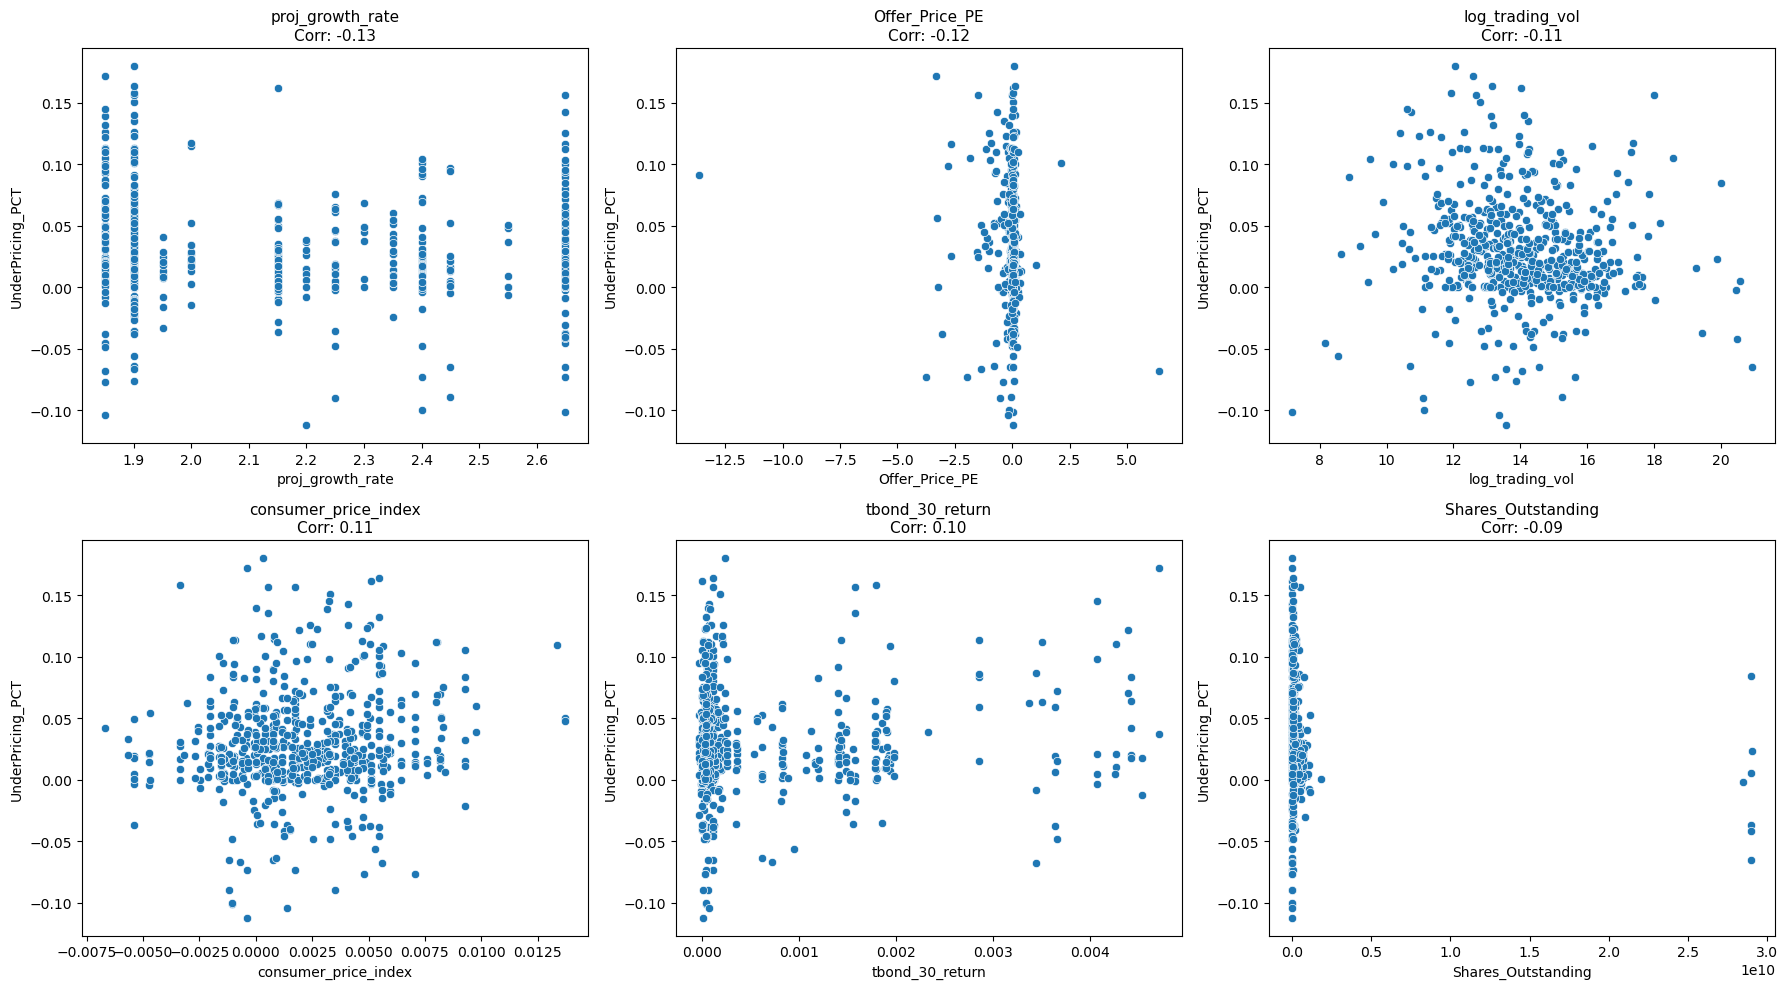

In [43]:
# ---------------------------------------
# Correlation Analysis: Top 6 strongest financial predictors of underpricing
# ---------------------------------------

# Remove rows with missing values in selected columns
df_clean = df_filtered[['UnderPricing_PCT'] + financial_factors].dropna()

# Calculate correlation of each factor with underpricing
full_corr = df_clean.corr()['UnderPricing_PCT'].drop('UnderPricing_PCT')

# Get top 6 features with highest absolute correlation
top_n = full_corr.abs().sort_values(ascending=False).head(6).index

# Plot scatter plots of top correlated variables
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, factor in enumerate(top_n):
    corr_value = full_corr[factor]
    sns.scatterplot(data=df_clean, x=factor, y='UnderPricing_PCT', ax=axes[i])
    axes[i].set_title(f'{factor}\nCorr: {corr_value:.2f}', fontsize=11)
    axes[i].set_xlabel(factor)
    axes[i].set_ylabel('UnderPricing_PCT')

plt.tight_layout()
plt.show()


In [44]:
# ---------------------------------------
# Print full correlation ranking (absolute strength) with underpricing
# ---------------------------------------

# Recalculate to ensure freshness
df_clean = df_filtered[['UnderPricing_PCT'] + financial_factors].dropna()
full_corr = df_clean.corr()['UnderPricing_PCT'].drop('UnderPricing_PCT')

print("All correlations with UnderPricing_PCT (sorted):")
print(full_corr.sort_values(key=abs, ascending=False))


All correlations with UnderPricing_PCT (sorted):
proj_growth_rate                              -0.125073
Offer_Price_PE                                -0.117751
log_trading_vol                               -0.112181
consumer_price_index                           0.109127
tbond_30_return                                0.100180
Shares_Outstanding                            -0.091986
div_pct                                       -0.070009
tbill_30_return                                0.067212
Total_Return_Factor                           -0.057511
Gross_Profit_Margin                            0.053619
Return_on_Equity                              -0.028584
Current_EPS                                   -0.027722
Cash_Conversion_Cycle_Days                     0.026687
Operating_Profit_Margin_Before_Depreciation    0.024999
P_E_Incl_Extra                                -0.017515
Return_on_Assets                              -0.010322
P_E_Excl_Extra                                 0.001229

In [45]:
# ---------------------------------------
# Compute correlations between UnderPricing_PCT and financial factors for each industry group
# ---------------------------------------

# Initialize an empty dictionary to store correlation DataFrames for each industry
industry_corrs = {}

# Group the dataset by 17-industry classification (cat17) and compute correlations within each group
for industry, group_df in df_filtered.groupby('cat17'):
    
    # Dictionary to store correlations for this industry
    correlations = {}
    
    # Iterate over each financial factor
    for factor in financial_factors:
        # Create a mini DataFrame for correlation computation
        pair_df = group_df[['UnderPricing_PCT', factor]].dropna()
        
        # Compute correlation if sufficient data exists, else assign NaN
        if not pair_df.empty:
            corr = pair_df['UnderPricing_PCT'].corr(pair_df[factor])
            correlations[factor] = corr
        else:
            correlations[factor] = np.nan

    # Convert correlation dictionary to a DataFrame
    corr_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['Correlation'])

    # Add column for absolute correlation (for sorting and ranking)
    corr_df['Abs_Correlation'] = corr_df['Correlation'].abs()

    # Sort by absolute correlation (strongest relationships first)
    corr_df = corr_df.sort_values(by='Abs_Correlation', ascending=False)

    # Store in the dictionary with industry name as key
    industry_corrs[industry] = corr_df


c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2742: RuntimeWarning:

invalid value encountered in subtract

c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

c:\ProgramData\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2742: RuntimeWarning:

invalid value encountered in subtract



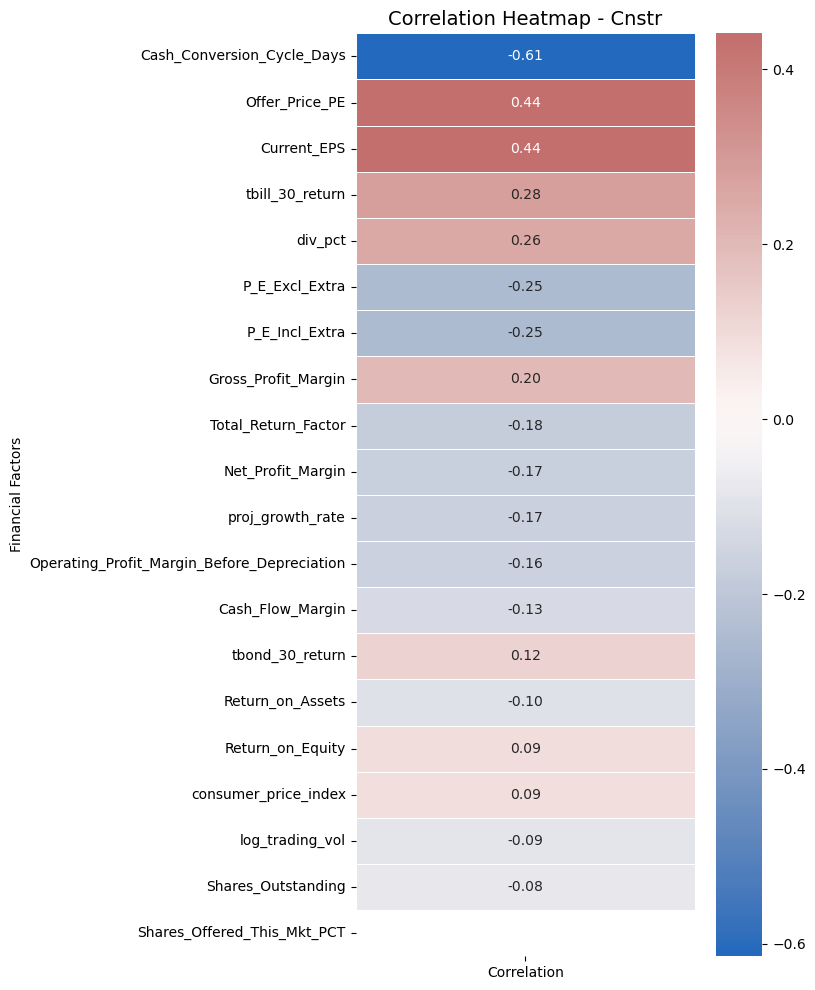

In [46]:
# ---------------------------------------
# Plotting heatmap for specific industry correlation (if using industry-level data)
# ---------------------------------------

def plot_industry_correlation_heatmap(industry_name, industry_corrs):
    """
    Plots a heatmap of correlations between financial factors and underpricing for a specific industry.
    
    Parameters:
    - industry_name: string (e.g., 'Cnstr')
    - industry_corrs: dictionary mapping industry names to correlation DataFrames
    """
    df = industry_corrs.get(industry_name)

    if df is None or df.empty:
        print(f"No correlation data for industry: {industry_name}")
        return

    plt.figure(figsize=(8, 10))
    sns.heatmap(df[['Correlation']], annot=True, center=0, cmap='vlag', fmt=".2f", linewidths=0.5)
    plt.title(f'Correlation Heatmap - {industry_name}', fontsize=14)
    plt.ylabel('Financial Factors')
    plt.tight_layout()
    plt.show()

# Example: Plot heatmap for construction industry
plot_industry_correlation_heatmap("Cnstr", industry_corrs)
